In [1]:
%matplotlib inline

In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

In [6]:
df = pd.read_csv('C:/Users/caras/PTUA2026/Lab04/data/summer-travel-gps-full.csv')
df.head()

,lat,lon,date,city,country
0,51.481292,-0.451011,05/14/2014 09:07,West Drayton,United Kingdom
1,51.474005,-0.450999,05/14/2014 09:22,Hounslow,United Kingdom
2,51.478199,-0.446081,05/14/2014 10:51,Hounslow,United Kingdom
3,51.478199,-0.446081,05/14/2014 11:24,Hounslow,United Kingdom
4,51.474146,-0.451562,05/14/2014 11:38,Hounslow,United Kingdom


In [12]:
# Q1: how to get 2 columns from the dataframe (city and country)?
df.iloc[:, 3:5]

,city,country
0,West Drayton,United Kingdom
1,Hounslow,United Kingdom
2,Hounslow,United Kingdom
3,Hounslow,United Kingdom
4,Hounslow,United Kingdom
...,...,...
1754,Munich,Germany
1755,Munich,Germany
1756,Munich,Germany
1757,Munich,Germany


In [13]:
df[["city", "country"]]

,city,country
0,West Drayton,United Kingdom
1,Hounslow,United Kingdom
2,Hounslow,United Kingdom
3,Hounslow,United Kingdom
4,Hounslow,United Kingdom
...,...,...
1754,Munich,Germany
1755,Munich,Germany
1756,Munich,Germany
1757,Munich,Germany


In [15]:
# Q2: how to get the first 5 rows of the "city" column?
df['city'][:5]

0    West Drayton
1        Hounslow
2        Hounslow
3        Hounslow
4        Hounslow
Name: city, dtype: object

In [16]:
# Q3: how to use .loc to select the third row of the dataframe?
df.loc[3,]

lat               51.478199
lon               -0.446081
date       05/14/2014 11:24
city               Hounslow
country      United Kingdom
Name: 3, dtype: object

In [17]:
# Q4: how to use .loc to select the first row in "country" column?
df["country"].loc[1,]

'United Kingdom'

In [18]:
# Q5: how to select the first 4 rows of ['city', 'date'] columns?
df[["city","date"]].loc[0:3]

,city,date
0,West Drayton,05/14/2014 09:07
1,Hounslow,05/14/2014 09:22
2,Hounslow,05/14/2014 10:51
3,Hounslow,05/14/2014 11:24


In [23]:
# use .iloc for integer position based indexing
# Q6: how to get the value from the row in position 3 and the column in position 2
df.iloc[3,1]

np.float64(-0.446081)

In [31]:
df = pd.read_csv("C:/Users/caras/PTUA2026/Lab04/data/summer-travel-gps-simplified.csv")
df.tail()

,lat,lon,date,city,country
173,41.044556,28.983286,07/08/2014 16:44,Istanbul,Turkey
174,41.008992,28.968268,07/08/2014 20:03,Istanbul,Turkey
175,41.043487,28.985488,07/08/2014 22:18,Istanbul,Turkey
176,40.977637,28.823879,07/09/2014 09:03,Istanbul,Turkey
177,48.357110,11.791346,07/09/2014 13:20,Munich,Germany


In [32]:
# Q9: create a Series of true/false, indicating if each "city" row in the column is equal to "Munich"
df['Munich'] = df['city'] == 'Munich'
print(df)

           lat        lon              date          city         country  \
0    51.481292  -0.451011  05/14/2014 09:07  West Drayton  United Kingdom   
1    38.781775  -9.137544  05/14/2014 15:11        Lisbon        Portugal   
2    38.711050  -9.139739  05/14/2014 16:40        Lisbon        Portugal   
3    38.715637  -9.120558  05/14/2014 18:25        Lisbon        Portugal   
4    38.711977  -9.141788  05/14/2014 19:26        Lisbon        Portugal   
..         ...        ...               ...           ...             ...   
173  41.044556  28.983286  07/08/2014 16:44      Istanbul          Turkey   
174  41.008992  28.968268  07/08/2014 20:03      Istanbul          Turkey   
175  41.043487  28.985488  07/08/2014 22:18      Istanbul          Turkey   
176  40.977637  28.823879  07/09/2014 09:03      Istanbul          Turkey   
177  48.357110  11.791346  07/09/2014 13:20        Munich         Germany   

     Munich  
0     False  
1     False  
2     False  
3     False  
4    

In [52]:
# pandas logical operators are: | for or, & for and, ~ for not
# these must be grouped by using parentheses
# Q10: what cities were visited in spain that were not barcelona? Create a dataframe for it. 
not_barcelona = df[(df['country'] == 'Spain') & ~(df['city'] == 'Barcelona')]
print(not_barcelona)


           lat       lon              date                     city country  \
24   41.303911  2.105931  05/18/2014 22:35     El Prat de Llobregat   Spain   
25   41.289946  2.064590  05/18/2014 23:04               Viladecans   Spain   
126  41.306752  2.097624  06/12/2014 17:19     El Prat de Llobregat   Spain   
127  41.304333  2.072728  06/12/2014 17:49     El Prat de Llobregat   Spain   
131  41.358460  2.128701  06/13/2014 11:35  Hospitalet de Llobregat   Spain   
138  41.294761  2.059722  06/20/2014 22:15               Viladecans   Spain   

     Munich  
24    False  
25    False  
126   False  
127   False  
131   False  
138   False  


In [42]:
# Q11: select rows where either the city is munich, or the country is serbia
df[(df["city"] == 'Munich') | (df["country"] == "Serbia")]


,lat,lon,date,city,country,Munich
139,44.821164,20.289821,06/21/2014 01:59,Belgrade,Serbia,False
140,44.820414,20.463465,06/21/2014 18:44,Belgrade,Serbia,False
141,44.761583,19.577904,06/22/2014 07:58,Slepčević,Serbia,False
177,48.357110,11.791346,07/09/2014 13:20,Munich,Germany,True


In [56]:
# Q12: how many observations are west of the prime meridian?
len(df[(df['lon'] < 0)])


24

In [57]:
# Q13: get all rows that contain a city that starts with the letter G
df[df['city'].str.startswith('G')]
   

,lat,lon,date,city,country,Munich
62,50.273632,18.729429,06/02/2014 06:39,Gliwice,Poland,False
114,48.282940,8.199630,06/10/2014 13:33,Gutach,Germany,False
115,48.389029,8.021342,06/10/2014 13:48,Gengenbach,Germany,False
152,40.187825,20.079303,07/04/2014 17:42,Gjirokastër,Albania,False


In [63]:
# Q14: how many unique cities and countries in the dataset? 
# Also can you check missing values for the dataframe
df['city'].value_counts().sort_index()


city
Algueirão-Mem Martins    1
Alpirsbach               1
Athens                   3
Attica                   1
Aveiro District          1
                        ..
Zendek                   1
Zibreira                 1
Ústí nad Orlicí          1
Úvaly                    1
Český Brod               1
Name: count, Length: 91, dtype: int64

In [64]:
df['country'].value_counts().sort_index()

country
Albania                    2
Bosnia and Herzegovina     3
Croatia                    3
Czech Republic            30
Germany                   32
Greece                    12
Kosovo                     1
Macedonia (FYROM)          1
Montenegro                 1
Poland                    20
Portugal                  23
Serbia                     3
Spain                     34
Turkey                    12
United Kingdom             1
Name: count, dtype: int64

In [70]:
df.isnull().sum()

lat        0
lon        0
date       0
city       0
country    0
Munich     0
dtype: int64

In [74]:
# Q15: group by country name and show the city names in each of the country
df.groupby('country')['city'].value_counts()

country                 city                   
Albania                 Berat                       1
                        Gjirokastër                 1
Bosnia and Herzegovina  Sarajevo                    2
                        Mostar                      1
Croatia                 Dubrovnik                   1
                                                   ..
Spain                   El Prat de Llobregat        3
                        Viladecans                  2
                        Hospitalet de Llobregat     1
Turkey                  Istanbul                   12
United Kingdom          West Drayton                1
Name: count, Length: 91, dtype: int64

In [77]:
# load the location data set, indexed by the date field
# and, parse the dates so they're no longer strings but now rather Python datetime objects
# this lets us do date and time based operations on the data set
dt = pd.read_csv("C:/Users/caras/PTUA2026/Lab04/data/summer-travel-gps-full.csv", index_col='date', parse_dates=True)
dt.head()

,lat,lon,city,country
date,,,,
2014-05-14 09:07:00,51.481292,-0.451011,West Drayton,United Kingdom
2014-05-14 09:22:00,51.474005,-0.450999,Hounslow,United Kingdom
2014-05-14 10:51:00,51.478199,-0.446081,Hounslow,United Kingdom
2014-05-14 11:24:00,51.478199,-0.446081,Hounslow,United Kingdom
2014-05-14 11:38:00,51.474146,-0.451562,Hounslow,United Kingdom


In [90]:
print(dt.index)

DatetimeIndex(['2014-05-14 09:07:00', '2014-05-14 09:22:00',
               '2014-05-14 10:51:00', '2014-05-14 11:24:00',
               '2014-05-14 11:38:00', '2014-05-14 12:23:00',
               '2014-05-14 12:38:00', '2014-05-14 15:11:00',
               '2014-05-14 15:25:00', '2014-05-14 15:41:00',
               ...
               '2014-07-09 06:03:00', '2014-07-09 06:18:00',
               '2014-07-09 09:03:00', '2014-07-09 09:18:00',
               '2014-07-09 13:11:00', '2014-07-09 13:13:00',
               '2014-07-09 13:14:00', '2014-07-09 13:17:00',
               '2014-07-09 13:18:00', '2014-07-09 13:20:00'],
              dtype='datetime64[ns]', name='date', length=1759, freq=None)


In [111]:
dt.index = pd.to_datetime(dt.index, format='%y/%m/%d') 
print(dt.head())

                           lat       lon          city         country
date                                                                  
2014-05-14 09:07:00  51.481292 -0.451011  West Drayton  United Kingdom
2014-05-14 09:22:00  51.474005 -0.450999      Hounslow  United Kingdom
2014-05-14 10:51:00  51.478199 -0.446081      Hounslow  United Kingdom
2014-05-14 11:24:00  51.478199 -0.446081      Hounslow  United Kingdom
2014-05-14 11:38:00  51.474146 -0.451562      Hounslow  United Kingdom


In [94]:
print(dt.index.dtype)

datetime64[ns]


In [112]:
dt.head()

,lat,lon,city,country
date,,,,
2014-05-14 09:07:00,51.481292,-0.451011,West Drayton,United Kingdom
2014-05-14 09:22:00,51.474005,-0.450999,Hounslow,United Kingdom
2014-05-14 10:51:00,51.478199,-0.446081,Hounslow,United Kingdom
2014-05-14 11:24:00,51.478199,-0.446081,Hounslow,United Kingdom
2014-05-14 11:38:00,51.474146,-0.451562,Hounslow,United Kingdom


In [102]:
# Q16: is the timestamp index unique? How can you use code to find it? 
dt.index.is_unique

False

In [105]:
dt[dt.index.duplicated(keep=False)]

,lat,lon,city,country
date,,,,
2014-07-05 00:52:00,38.489004,21.340031,Dytiki Ellada,Greece
2014-07-05 00:52:00,38.541479,21.284091,Dytiki Ellada,Greece


In [106]:
# Q17: drop duplicate index 
dt = dt[~dt.index.duplicated(keep='first')]

In [110]:
# Q18: create a weekday and a weekend dataframe
weekday_dt = dt[dt.index.dayofweek < 5]

weekend_dt = dt[dt.index.dayofweek > 4]

In [114]:
# Q19: calculate and plot the number of observations each day of the week has
n_obs_week = dt.index.dayofweek.value_counts().sort_index()
n_obs_week

date
0    263
1    254
2    254
3    256
4    218
5    268
6    245
Name: count, dtype: int64

In [120]:
n_obs_week = dt.index.day_name().value_counts()
print(n_obs_week)

date
Saturday     268
Monday       263
Thursday     256
Wednesday    254
Tuesday      254
Sunday       245
Friday       218
Name: count, dtype: int64


<Axes: xlabel='date'>

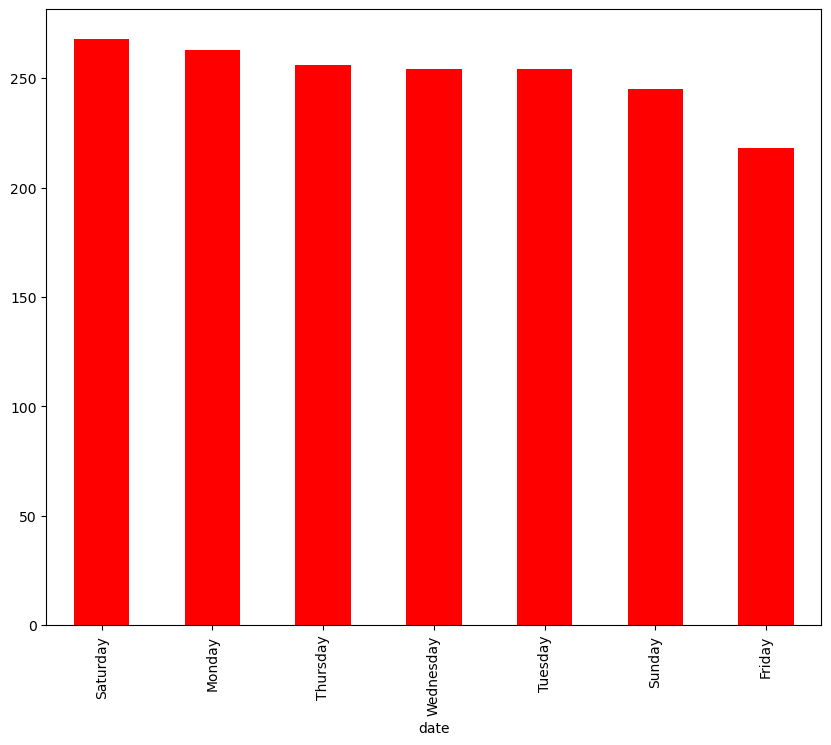

In [130]:
n_obs_week.columns = ['Count']
n_obs_week['Count'].plot(kind = 'bar', figsize=(10, 8), color='red')

In [131]:
n_obs_week.index.name = 'Day of Week'
n_obs_week.columns = ['Count']
n_obs_week.tail()

,Count
Day of Week,
Thursday,256
Wednesday,254
Tuesday,254
Sunday,245
Friday,218


<Axes: title={'center': 'Observation Count\n'}, xlabel='Day of Week'>

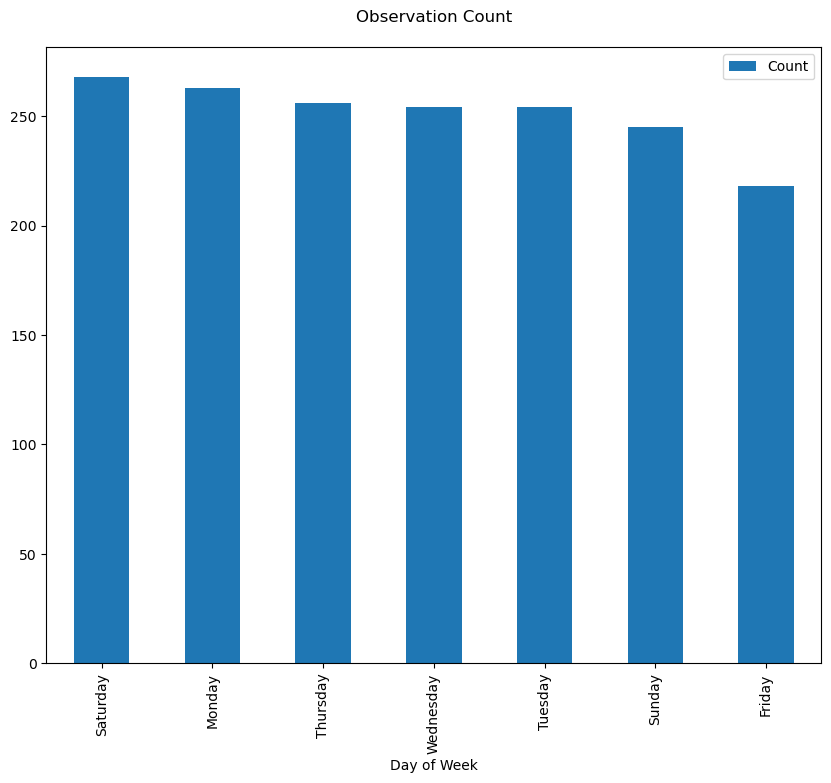

In [134]:
n_obs_week.plot(kind = 'bar', figsize=(10, 8), title='Observation Count\n')